Порядок работы в notebook
1. Загрузить датасет
pd.read_csv, посмотреть df.head(), df.shape, df.dtypes
2. Описать датасет
Что за данные, сколько строк, какие поля
3. Почистить данные
df.isna().sum(), убрать NaN, проверить типы
4. Descriptive statistics
df.describe(), mean/median/std для 4 числовых полей
5. Простые графики
4 графика, 3 разных типа
6. Подробный анализ
4 сравнения — тут уже начинаешь замечать интересные связи
7. Трансформация
Добавить 1-2 новых колонки
8. Гипотезы
Вот здесь — после того как посмотрели на данные, выдвигаете 2 гипотезы и проверяете их графиками/статистикой
9. Discussion
После каждого блока пишете пару предложений что увидели

# Flight Price Analysis
### Kazykina Sofya & Gainullina Amina

In [73]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110


---
## Dataset Description
The dataset contains information about domestic flights in India.

| Column | Type | Description |
|---|---|---|
| `airline` | categorical | Name of the airline |
| `flight` | categorical | Flight code (removed during cleanup) |
| `source_city` | categorical | City of departure |
| `departure_time` | categorical | Time-of-day label for departure |
| `stops` | categorical (text) | Number of stops: zero / one / two_or_more |
| `arrival_time` | categorical | Time-of-day label for arrival |
| `destination_city` | categorical | City of arrival |
| `class` | categorical | Ticket class: Economy / Business |
| `duration` | numerical | Flight duration in hours |
| `days_left` | numerical | Days between booking and departure |
| `price` | numerical | Ticket price in INR |

In [74]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [75]:
# цена за час полёта
df['price_per_hour'] = df['price'] / df['duration']

df[['airline', 'duration', 'price', 'price_per_hour']].head(10)

,airline,duration,price,price_per_hour
0,SpiceJet,2.17,5953,2743.317972
1,SpiceJet,2.33,5953,2554.935622
2,AirAsia,2.17,5956,2744.700461
3,Vistara,2.25,5955,2646.666667
4,Vistara,2.33,5955,2555.793991
5,Vistara,2.33,5955,2555.793991
6,Vistara,2.08,6060,2913.461538
7,Vistara,2.17,6060,2792.626728
8,GO_FIRST,2.17,5954,2743.778802
9,GO_FIRST,2.25,5954,2646.222222


In [76]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


убрала колонку unnamed

---
## Data Cleanup

In [77]:
#1. Check for missing values
print('Missing values per column:')
print(df.isna().sum())
print(f'\nTotal missing: {df.isna().sum().sum()}')

Missing values per column:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Total missing: 0


In [78]:
#2. Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Duplicate rows: 0
No duplicates found — dataset is clean.


In [79]:
#3. Convert 'stops' text values to integers
print('Unique values in stops:', df['stops'].unique())

stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
df['num_stops'] = df['stops'].map(stops_map)

unmapped = df['num_stops'].isna().sum()
print(f'Unmapped stops values: {unmapped}')

if unmapped > 0:
    print('Dropping rows with unmapped stops...')
    df = df.dropna(subset=['num_stops'])

df['num_stops'] = df['num_stops'].astype(int)
print('\nnum_stops value counts:')
print(df['num_stops'].value_counts().sort_index())

Unique values in stops: <ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
Unmapped stops values: 0

num_stops value counts:
num_stops
0     36004
1    250863
2     13286
Name: count, dtype: int64


In [80]:
#4. Drop columns with no analytical value
cols_to_drop = [c for c in ['stops', 'flight'] if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f'Dropped columns: {cols_to_drop}')

Dropped columns: ['stops', 'flight']


In [81]:
#5. Final result
print('Final dataset shape:', df.shape)
print('\nColumn dtypes after cleanup:')
print(df.dtypes)
print('\nFirst rows of cleaned dataset:')
df.head()

Final dataset shape: (300153, 10)

Column dtypes after cleanup:
airline                 str
source_city             str
departure_time          str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
num_stops             int64
dtype: object

First rows of cleaned dataset:


,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,0


In [82]:
# Descriptive stats including num_stops
df[['price', 'duration', 'days_left', 'num_stops']].agg(['mean', 'median', 'std']).round(2)

,price,duration,days_left,num_stops
mean,20889.66,12.22,26.00,0.92
median,7425.00,11.25,26.00,1.00
std,22697.77,7.19,13.56,0.40


дальше идут графики

<Axes: xlabel='price', ylabel='Count'>

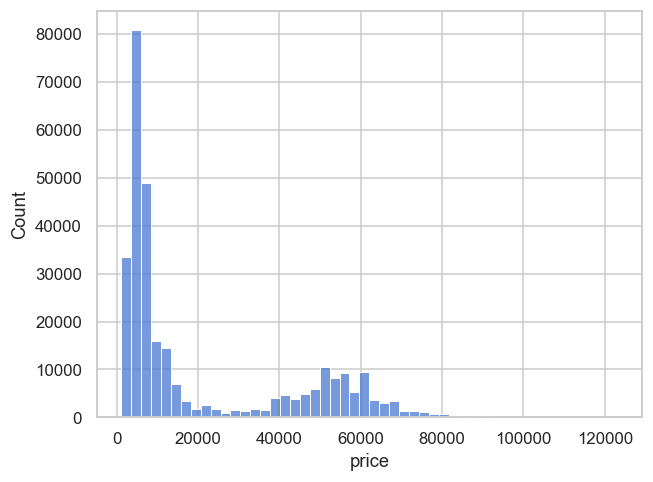

In [83]:
sns.histplot(df['price'], bins=50)

In [84]:
print("Новые колонки:")
print(df.dtypes)

Новые колонки:
airline                 str
source_city             str
departure_time          str
arrival_time            str
destination_city        str
class                   str
duration            float64
days_left             int64
price                 int64
num_stops             int64
dtype: object


Датасет не содержал пропущенных значений. Убрали колонку `Unnamed: 0` 
при загрузке, колонку `flight` (номер рейса — не несёт аналитической ценности) 
и преобразовали `stops` из текстового формата в числовой (`num_stops`).

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   departure_time    300153 non-null  str    
 3   arrival_time      300153 non-null  str    
 4   destination_city  300153 non-null  str    
 5   class             300153 non-null  str    
 6   duration          300153 non-null  float64
 7   days_left         300153 non-null  int64  
 8   price             300153 non-null  int64  
 9   num_stops         300153 non-null  int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 35.6 MB


In [86]:
df.groupby("airline")["price"].mean()   
df.groupby("class")["price"].median() 

class
Business    53164.0
Economy      5772.0
Name: price, dtype: float64

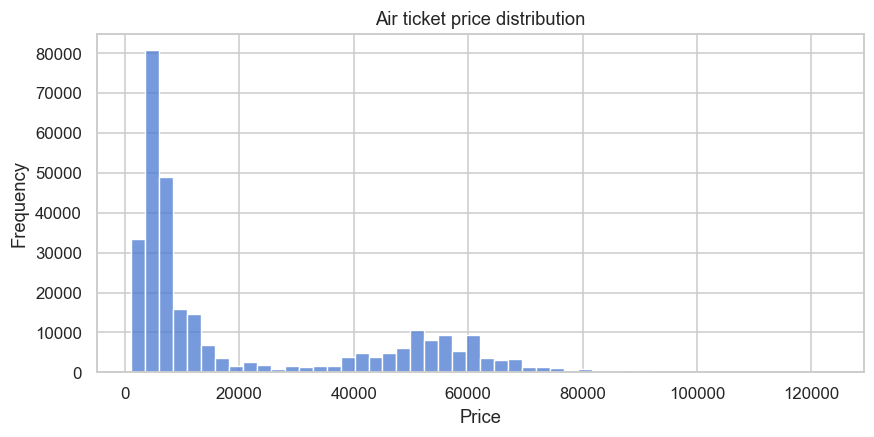

In [87]:
plt.figure(figsize=(9,4))
sns.histplot(df['price'], bins=50)
plt.title('Air ticket price distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

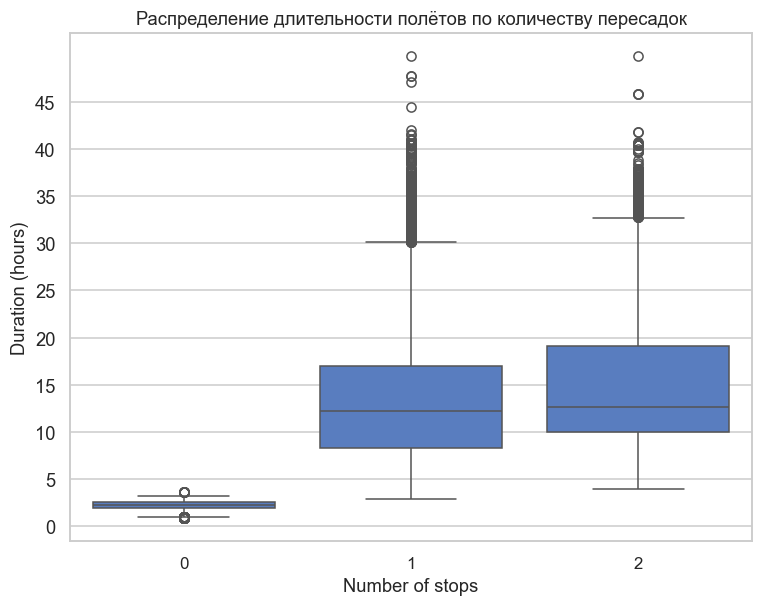

In [88]:
plt.figure(figsize=(8,6))
sns.boxplot(x='num_stops', y='duration', data=df)
plt.title('Распределение длительности полётов по количеству пересадок')
plt.xlabel('Number of stops')
plt.ylabel('Duration (hours)')
plt.yticks(fontsize=12)
max_dur = int(df['duration'].max()) + 1
plt.yticks(range(0, max_dur, 5))
plt.show()

In [89]:
print(df['duration'].mean())

12.221020812718846


boxplot цены в зависимости от количества пересадок

In [90]:
df

,airline,source_city,departure_time,arrival_time,destination_city,class,duration,days_left,price,num_stops
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,2.17,1,5953,0
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,2.33,1,5953,0
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,2.17,1,5956,0
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,2.25,1,5955,0
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,2.33,1,5955,0
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,Evening,Hyderabad,Business,10.08,49,69265,1
300149,Vistara,Chennai,Afternoon,Night,Hyderabad,Business,10.42,49,77105,1
300150,Vistara,Chennai,Early_Morning,Night,Hyderabad,Business,13.83,49,79099,1
300151,Vistara,Chennai,Early_Morning,Evening,Hyderabad,Business,10.00,49,81585,1


<Axes: ylabel='duration'>

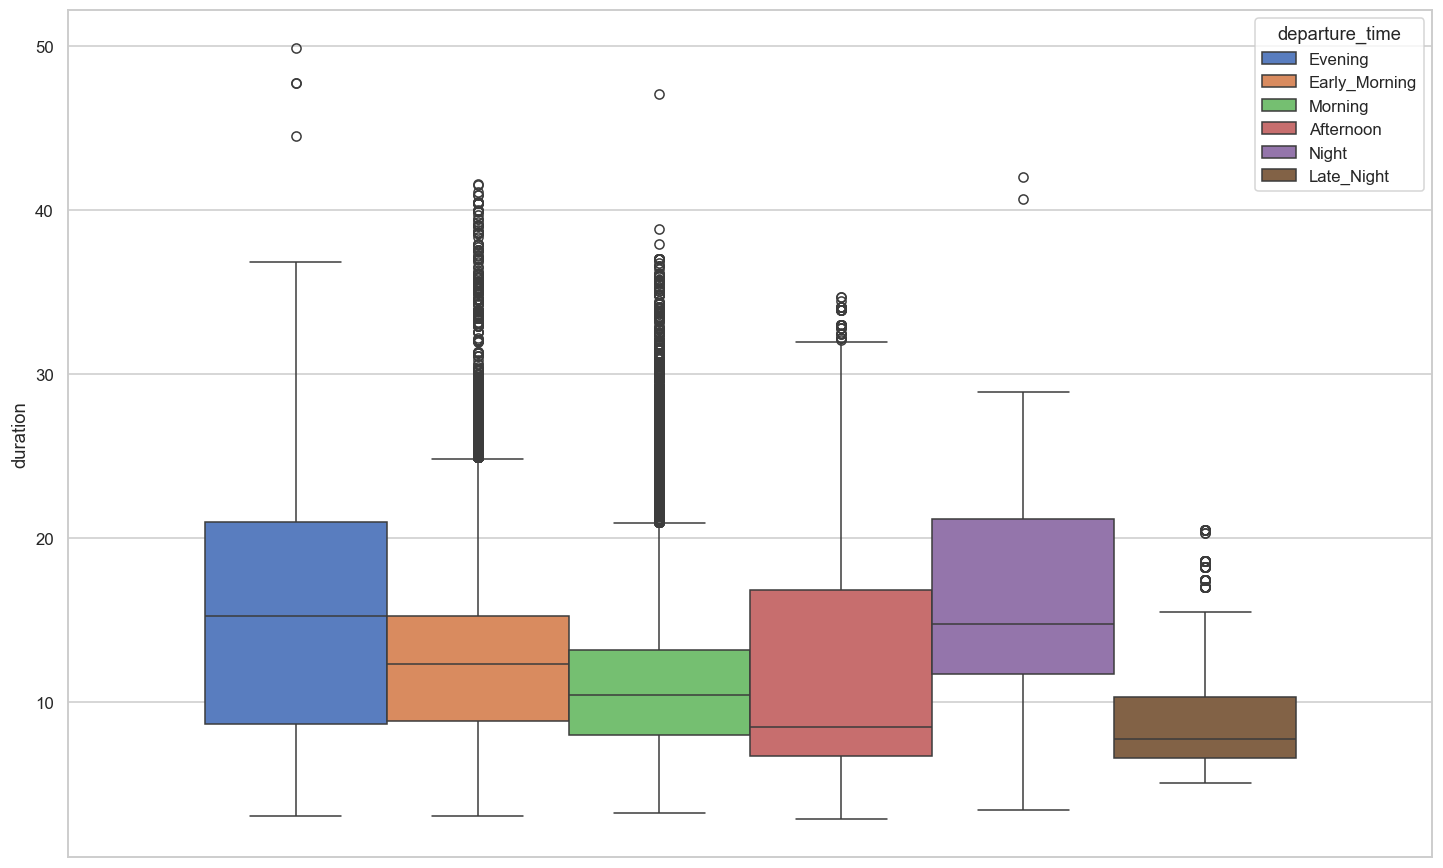

In [91]:
plt.figure(figsize=(16,10))
sns.boxplot(y='duration', data=df[df.num_stops == 1], hue="departure_time")
# plt.title('Распределение цен по количеству пересадок')
# plt.xlabel('Number of stops')
# plt.ylabel('Price')
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.show()

In [92]:
df.groupby("num_stops")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
num_stops,,,,,,,,
0,36004.0,9375.938535,10623.008293,1105.0,2586.0,4499.0,8064.0,59573.0
1,250863.0,22900.992482,23626.066584,1105.0,5136.0,7959.0,48851.0,123071.0
2,13286.0,14113.450775,17664.332033,1966.0,6432.0,8307.0,13419.0,117307.0
